**Hernandez Damian Josue Valdemar**

**Portafolio eficiente y CAMP**

Activo a = VOLARA ; Activo b = WALMART


/tmp/ipykernel_1024/3680728664.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=finicio, end=ffinal, progress=False)


A. El rendimiento del activo WALMART es -0.00026337688296699423
B. El rendimiento del activo VOLARA es 2.8506214290352272e-05
C. La desviacion estandar (volatilidad) del activo WALMART es 0.021172800889804177
D. La desviacion estandar (volatilidad) del activo VOLARA es 0.016401275802148358
Covarianza entre el activo VOLARA y WALMART es 9.383464574726248e-05
E. Correlacion entre el activo VOLARA y WALMART es 0.2702136436174568
F. Pesos del portafolio de min varianza para VOLARA y WALMART respectivamente
Wa  = 0.669258743357283 Wb  = 0.3307412566427171
G. Rendimiento del portafolio de min varianza: -6.803156808931092e-05
H. Volatilidad del portafolio de min varianza: 0.014528139156923659


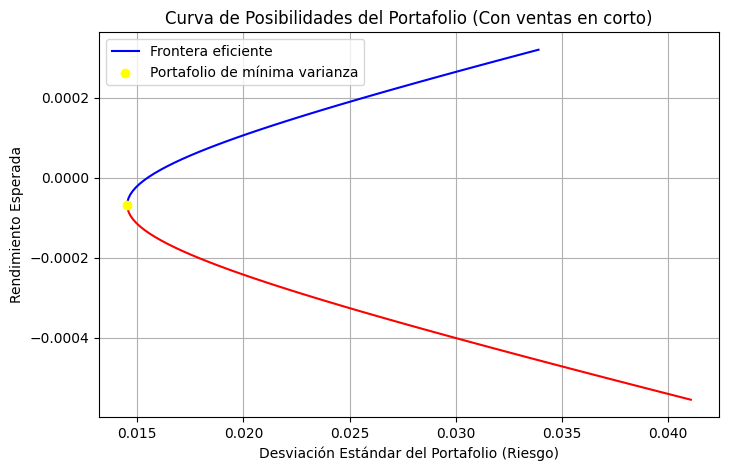

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def portafolio(a, b, finicio, ffinal):
  ordenar = sorted([a,b])
  a = ordenar[0]
  b=ordenar[1]
  print( "Activo a = " + a + " ; Activo b = " + b)
  tickers = ["a", "b"]

# Descargar los datos históricos
  data = yf.download(tickers, start=finicio, end=ffinal, progress=False)

# Obtener solo la columna de "Adj Close" (Precio de cierre ajustado)
  closing_prices = data["Close"]
#print(closing_prices)

# Calcular los rendimientos diarios
  returns = closing_prices.pct_change().dropna()
#print(returns)

# Calcular el rendimiento esperado (media de los retornos)
  media = returns.mean()
  #print(media)
  rend_a = media.iloc[0]
  rend_b = media.iloc[1]
  print("A. El rendimiento del activo "+ b +" es "+ str(rend_b))
  print("B. El rendimiento del activo "+ a + " es "+ str(rend_a))

# Calcular la varianza de los retornos
  variance = returns.var()
  var_a =  variance.iloc[0]
  var_b =  variance.iloc[1]
#print("La varianza del activo" + a + " es "+ str(var_a))
#print("La varianza del activo" + b +" es "+ str(var_b))

# Calcular la desviación estándar (volatilidad) de cada acción
  std_dev = returns.std()
  std_a = std_dev.iloc[0]
  std_b = std_dev.iloc[1]
  print("C. La desviacion estandar (volatilidad) del activo " +b+ " es "+ str(std_b))
  print("D. La desviacion estandar (volatilidad) del activo " + a + " es "+ str(std_a))

# Calcular la matriz de covarianza entre las acciones
  cov = returns.cov().iloc[0, 1]
  print("Covarianza entre el activo " + a +" y "+ b+ " es " +str(cov))

#Calcular correlacion entre los activos
  corr = returns.corr()
  print("E. Correlacion entre el activo " + a +" y "+ b+ " es " +str(corr.iloc[0, 1]))

#portafolio de min varianza
  var_cov = [ [var_a, cov, 1], [cov, var_b, 1], [1,1,0]]
  aux = [ [0], [0], [1]]
  inv_var_cov = np.linalg.inv(var_cov)
  pesos_PMV = np.dot(inv_var_cov, aux)
  print("F. Pesos del portafolio de min varianza para " + a +" y "+ b + " respectivamente")
  print( "Wa  = " + str(pesos_PMV[0][0]) + " Wb  = " + str(pesos_PMV[1][0]) )

# rendimiento y volatilidad del port de min varianza
  W_PMV = [ pesos_PMV[0][0], pesos_PMV[1][0]]
  Esp_act = [[rend_a], [rend_b]]
  V_C = [ [var_a, cov], [cov, var_b]]
  R_PMV = np.dot(W_PMV, Esp_act)
  print("G. Rendimiento del portafolio de min varianza: " + str(R_PMV[0]))
  V_PMV = np.dot(np.dot(W_PMV, V_C), np.transpose(W_PMV))
  volt_PMV = np.sqrt(V_PMV)
  print("H. Volatilidad del portafolio de min varianza: " + str(volt_PMV))

  # Pesos del portafolio (permitiendo ventas en corto, de -1 a 2)
  w_A = np.linspace(-1, 2, 100)
  w_B = 1 - w_A

# Rendimiento esperada del portafolio
  r_p = w_A * rend_a + w_B * rend_b

# Desviación estándar del portafolio
  sigma_p = np.sqrt(w_A**2 * var_a + w_B**2 * var_b + 2 * w_A * w_B * cov)
#Dividir para pintar la frontera eficiente
  front_efc = r_p >= R_PMV
  curva_pos = r_p<R_PMV

  plt.figure(figsize=(8, 5))
# Graficar la parte inferior en azul
  plt.plot(sigma_p[curva_pos], r_p[curva_pos], color="red", label="")
# Graficar la parte superior en naranja
  plt.plot(sigma_p[front_efc], r_p[front_efc], color="blue", label="Frontera eficiente")
# Marcar el portafolio de min varianza
  plt.scatter(volt_PMV, R_PMV, color="yellow", label="Portafolio de mínima varianza", zorder=3)
  plt.xlabel("Desviación Estándar del Portafolio (Riesgo)")
  plt.ylabel("Rendimiento Esperada")
  plt.title("Curva de Posibilidades del Portafolio (Con ventas en corto)")
  plt.legend()
  plt.grid(True)
  plt.show()






portafolio("VOLARA", "WALMART", "2024-01-01", "2024-12-31")

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def portafolio(a, b, c, finicio, ffinal):
  ordenar = sorted([a,b,c])
  a = ordenar[0]
  b=ordenar[1]
  c=ordenar[2]
  print( "Activo a = " + a + " ; Activo b = " + b + "; Mercado = "+ c)
  tickers = ["a", "b","c"]

# Descargar los datos históricos
  data = yf.download(tickers, start=finicio, end=ffinal, progress=False)

# Obtener solo la columna de "Adj Close" (Precio de cierre ajustado)
  closing_prices = data["Close"]
#print(closing_prices)

# Calcular los rendimientos diarios
  returns = closing_prices.pct_change().dropna()
#print(returns)

# Calcular el rendimiento esperado (media de los retornos)
  media = returns.mean()
  #print(media)
  rend_a = media.iloc[0]
  rend_b = media.iloc[1]
  rend_mercado = media.iloc[2]
  #print(" El rendimiento del activo "+ b +" es "+ str(rend_b))
  #print(" El rendimiento del activo "+ a + " es "+ str(rend_a))
  print("El rendimiento de mercado es "+ str(rend_mercado))

# Calcular la varianza de los retornos
  variance = returns.var()
  var_a =  variance.iloc[0]
  var_b =  variance.iloc[1]
  var_mercado = variance.iloc[2]
#print("La varianza del activo" + a + " es "+ str(var_a))
#print("La varianza del activo" + b +" es "+ str(var_b))


# Calcular la matriz de covarianza entre las acciones
  cov = returns.cov().iloc[0, 1]
  cov_beta1 = returns.cov().iloc[0, 2]
  cov_beta2 = returns.cov().iloc[1, 2]
#print("Covarianza entre el activo " + a +" y "+ b+ " es " +str(cov))

#Calcular betas de los activo
  beta1 = cov_beta1/var_mercado
  beta2 = cov_beta2/var_mercado
  print("Beta del activo " + a + " es " + str(beta1))
  print("Beta del activo " + b + " es " + str(beta2))

#Rendimientos esperados bajo CAPM
  rf = 0.11
  rend_a_capm = rf + beta1 * (rend_mercado - rf)
  rend_b_capm = rf + beta2 * (rend_mercado - rf)
  print("Rendimiento esperado bajo CAPM del activo " + a + " es " + str(rend_a_capm))
  print("Rendimiento esperado bajo CAPM del activo " + b + " es " + str(rend_b_capm))

  if(rend_a < rend_a_capm):
    print("El activo " + a + " está sobrevaluado")
  else:
    print("El activo " + a + " ) está subvaluado")

  if(rend_b < rend_b_capm):
    print("El activo " + b + " está sobrevaluado")
  else:
    print("El activo " + b + " está subvaluado")



portafolio("VOLARA", "WALMART","^MXX", "2024-01-01", "2024-12-31")

Activo a = VOLARA ; Activo b = WALMART; Mercado = ^MXX


/tmp/ipykernel_1024/1765512420.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=finicio, end=ffinal, progress=False)


El rendimiento de mercado es 0.0014146308048361882
Beta del activo VOLARA es 0.24436351155057276
Beta del activo WALMART es 0.2678680915712374
Rendimiento esperado bajo CAPM del activo VOLARA es 0.08346569788045438
Rendimiento esperado bajo CAPM del activo WALMART es 0.08091344438113324
El activo VOLARA está sobrevaluado
El activo WALMART está sobrevaluado
